# **🌳 '건물의 에너지 효율성 예측'과 관련된 데이터셋 입니다.**

'**건물의 에너지 효율성**'을 예측하는 모델을 제작해보세요.

✔️ **[파일] - [Drive에 사본 저장]**

# **[단계1] 데이터 불러오기**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
files.upload()

Saving energy_efficiency_data.csv to energy_efficiency_data (1).csv


{'energy_efficiency_data (1).csv': b'Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load\r\n0.98,514.5,294,110.25,7,2,0,0,15.55,21.33\r\n0.98,514.5,294,110.25,7,3,0,0,15.55,21.33\r\n0.98,514.5,294,110.25,7,4,0,0,15.55,21.33\r\n0.98,514.5,294,110.25,7,5,0,0,15.55,21.33\r\n0.9,563.5,318.5,122.5,7,2,0,0,20.84,28.28\r\n0.9,563.5,318.5,122.5,7,3,0,0,21.46,25.38\r\n0.9,563.5,318.5,122.5,7,4,0,0,20.71,25.16\r\n0.9,563.5,318.5,122.5,7,5,0,0,19.68,29.6\r\n0.86,588,294,147,7,2,0,0,19.5,27.3\r\n0.86,588,294,147,7,3,0,0,19.95,21.97\r\n0.86,588,294,147,7,4,0,0,19.34,23.49\r\n0.86,588,294,147,7,5,0,0,18.31,27.87\r\n0.82,612.5,318.5,147,7,2,0,0,17.05,23.77\r\n0.82,612.5,318.5,147,7,3,0,0,17.41,21.46\r\n0.82,612.5,318.5,147,7,4,0,0,16.95,21.16\r\n0.82,612.5,318.5,147,7,5,0,0,15.98,24.93\r\n0.79,637,343,147,7,2,0,0,28.52,37.73\r\n0.79,637,343,147,7,3,0,0,29.9,31.27\r\n0.79,637,343,147,7,4,0,0,29.63,30.93\r\n0.

In [ ]:
df = pd.read_csv('energy_efficiency_data.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall_Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    int64  
 8   Heating_Load               768 non-null    float64
 9   Cooling_Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


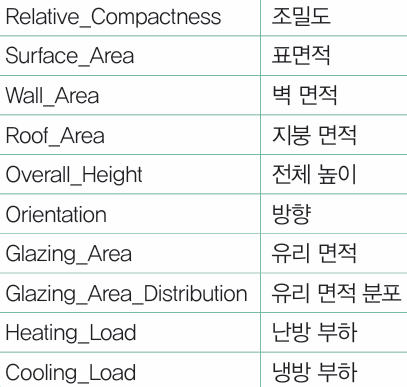

In [ ]:
df.describe() # 통계 정보 확인

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


# **[단계2] 데이터 체급 맞추기**

✔️ 해석?

전체 데이터는 768개, 상대 조밀도의 평균값은 0.76으로 매우 작은 값이다.

반면에 표면적 속성의 평균값은 671.70으로 **속성값들의 차이가 큰 것**을 알 수 있다. → 데이터 체급 맞추기(MinMaxScaler)

- 표면적: 외부 공기가 맞닿아 있는 모든 면의 넓이 합(표면적이 넓을수록 겨울에는 내부 열이 더 많이 방출되고, 여름에는 외부 열이 더 많이 유입됨.)

- 조밀도: 건물 부피에 비해 표면적이 얼마나 작은지를 나타내는 비율(조밀도가 높을 수록 정육면체에 가까워 열 보존 능력이 뛰어나고, 조밀도가 낮을 수록 열 손실에 취약)

In [ ]:
# 데이터의 체급을 똑같이 맞춰주기 위해서 MinMaxScaler를 불러오기
from sklearn.preprocessing import MinMaxScaler

# 0~1 사이의 값으로 스케일링하는 MinMaxScaler 객체 생성하기
scaler = MinMaxScaler(feature_range=(0, 1))

# df 데이터 프레임에 MinMaxScaler를 적용하기
scaled_data = scaler.fit_transform(df)

# 스케일된 데이터를 데이터 프레임으로 변환하기
df2 = pd.DataFrame(scaled_data, columns=df.columns)
df2.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,1.000000,0.000000,0.285714,0.000000,1.0,0.000000,0.0,0.0,0.257212,0.280905
1,1.000000,0.000000,0.285714,0.000000,1.0,0.333333,0.0,0.0,0.257212,0.280905
2,1.000000,0.000000,0.285714,0.000000,1.0,0.666667,0.0,0.0,0.257212,0.280905
3,1.000000,0.000000,0.285714,0.000000,1.0,1.000000,0.0,0.0,0.257212,0.280905
4,0.777778,0.166667,0.428571,0.111111,1.0,0.000000,0.0,0.0,0.399838,0.468085


# **[단계3] 데이터 전처리**

In [ ]:
df.isnull().sum() # ① 결측치 확인

,0
Relative_Compactness,0
Surface_Area,0
Wall_Area,0
Roof_Area,0
Overall_Height,0
Orientation,0
Glazing_Area,0
Glazing_Area_Distribution,0
Heating_Load,0
Cooling_Load,0


<Axes: >

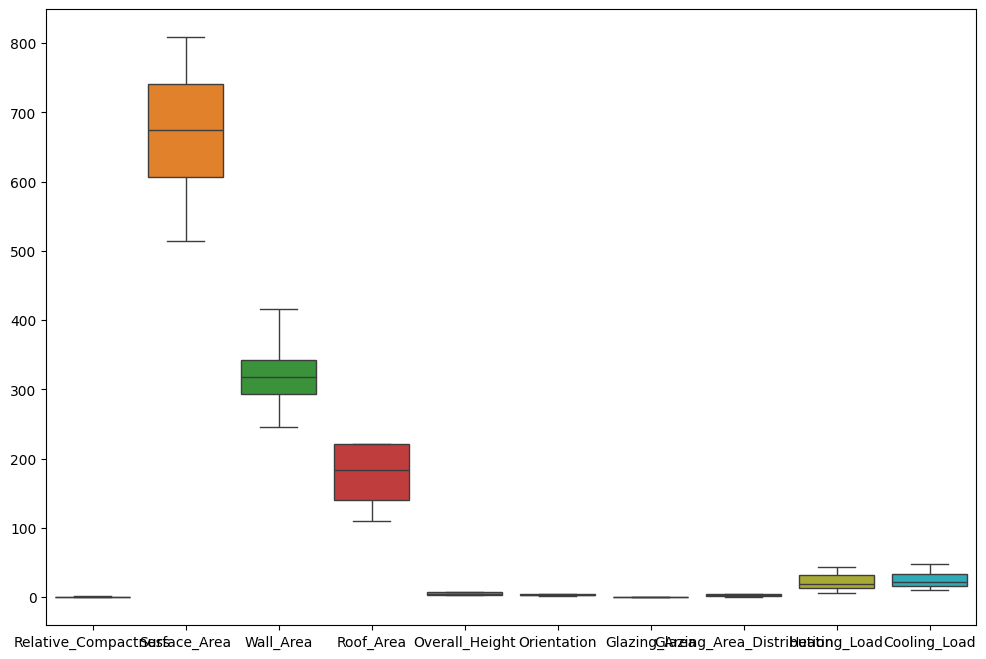

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8)) # 이미지	크기	설정하기
sns.boxplot(data=df) # ② 이상치 확인

# **[단계4] 상관계수 도출하고 핵심 속성 찾기**

In [ ]:
corr=df.corr(numeric_only=True)
corr

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
Relative_Compactness,1.000000e+00,-9.919015e-01,-2.037817e-01,-8.688234e-01,8.277473e-01,4.678592e-17,-2.960552e-15,-7.107006e-16,0.622272,0.634339
Surface_Area,-9.919015e-01,1.000000e+00,1.955016e-01,8.807195e-01,-8.581477e-01,-3.459372e-17,3.636925e-15,2.438409e-15,-0.658120,-0.672999
Wall_Area,-2.037817e-01,1.955016e-01,1.000000e+00,-2.923165e-01,2.809757e-01,-2.429499e-17,-8.567455e-17,2.067384e-16,0.455671,0.427117
Roof_Area,-8.688234e-01,8.807195e-01,-2.923165e-01,1.000000e+00,-9.725122e-01,-5.830058e-17,-1.759011e-15,-1.078071e-15,-0.861828,-0.862547
Overall_Height,8.277473e-01,-8.581477e-01,2.809757e-01,-9.725122e-01,1.000000e+00,4.492205e-17,1.489134e-17,-2.920613e-17,0.889431,0.895785
Orientation,4.678592e-17,-3.459372e-17,-2.429499e-17,-5.830058e-17,4.492205e-17,1.000000e+00,-9.406007e-16,-2.549352e-16,-0.002587,0.014290
Glazing_Area,-2.960552e-15,3.636925e-15,-8.567455e-17,-1.759011e-15,1.489134e-17,-9.406007e-16,1.000000e+00,2.129642e-01,0.269841,0.207505
Glazing_Area_Distribution,-7.107006e-16,2.438409e-15,2.067384e-16,-1.078071e-15,-2.920613e-17,-2.549352e-16,2.129642e-01,1.000000e+00,0.087368,0.050525
Heating_Load,6.222722e-01,-6.581202e-01,4.556712e-01,-8.618283e-01,8.894307e-01,-2.586534e-03,2.698410e-01,8.736759e-02,1.000000,0.975862
Cooling_Load,6.343391e-01,-6.729989e-01,4.271170e-01,-8.625466e-01,8.957852e-01,1.428960e-02,2.075050e-01,5.052512e-02,0.975862,1.000000


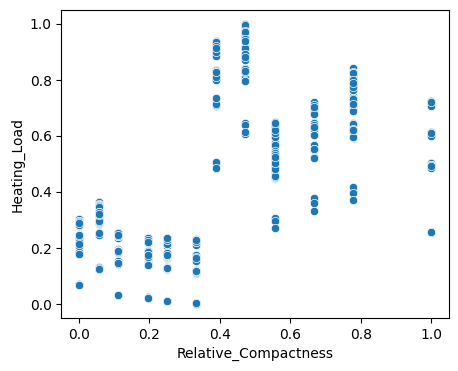

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(5,4)) # 이미지 크기 설정하기
# 산점도 그리기
sns.scatterplot(data=df2, x='Relative_Compactness', y='Heating_Load') #조밀도와 지붕면적 등등,,,이 에너지 효율 지표(난방 부하: Heating_Load)와 어떤 상관관계를 지니는지 확인
plt.show()

# **[단계4] 독립변수와 종속변수 설정하기**

In [ ]:
import numpy as np
X=np.array(df2.iloc[:,3]) # 지붕	면적(Roof	Area)을	독립	변수로	설정하기 (4열인 '지붕 면적(Roof_Area)' 데이터 전체를 배열로 변환)
y=df2.iloc[:,8] # 난방 부하(heating load)를 종속변수로 설정하기
X=X.reshape(-1,1) # 모델에 입력하기 위해 X를 1차원에서 2차원으로 변환하기

# **[단계5] 데이터 쪼개기**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.3, random_state=0)

# **[단계6] 단순 선형회귀 모델 제작**

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression() # 선형 회귀 모델 생성하기
model.fit(X_train, y_train) # 훈련 데이터로 모델 학습하기

LinearRegression()

In [ ]:
print(model.coef_, model.intercept_) # 단순 선형회귀 (난방 부하 = -0.577x지붕면적 + 0.788)

[-0.57657037] 0.7901278551283608


# **[단계7] 단순 선형회귀 모델 성능 평가**

In [ ]:
from sklearn.metrics import mean_squared_error #MSE를 계산 및 확인하기 위한 라이브러리
import numpy as np

Predicted = model.predict(X_test) #모델 예측
MSE = mean_squared_error(y_test, Predicted)
RMSE = np.sqrt(MSE) #sqrt() = 제곱근

print(f"MSE(평균제곱오차): {MSE:.2f}")
print(f"RMSE(평균제곱근오차): {RMSE:.2f}")

MSE(평균제곱오차): 0.02
RMSE(평균제곱근오차): 0.15


# **[단계8] 모델 성능 개선하기**

지붕 면적1개 특성으로 난방 부하를 예측하는 단순 선형회귀의 성능이 좋은편이지만 더 많은 속성을 추가하여 모델을 개선할 수 있다.

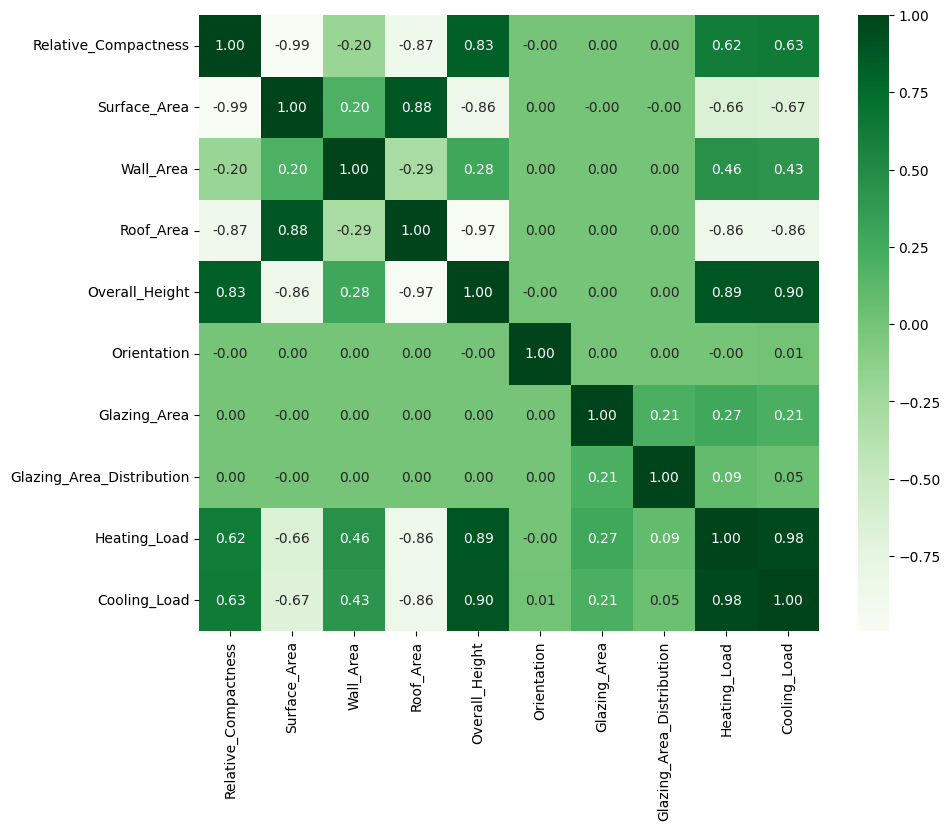

In [ ]:
# '히트맵' 활용하여 난방부하와 상관이 높은 속성
plt.figure(figsize=(10,8)) # 이미지 크기 설정하기
sns.heatmap(df2.corr(),annot=True, cmap='Greens', fmt='.2f') #초록색 칸에 소수점 2자리까지 상관계수 숫자 표현을 히트맵으로 표현
plt.show()

✔️ 해석?

난방 부하 속성은 건물 상대 조밀도, 표면적, 지붕 면적, 전체 높이 속성과
상관이 높다.

# **[단계9] 다중 선형회귀 모델 제작을 위해 데이터 쪼개기**

In [ ]:
# 독립 변수 설정하기(조밀도, 표면적, 지붕 면적, 전체 높이)
X2=df2.iloc[:,[0,1,3,4]] # df2: 정규화 수행한 데이터
y2=df2.iloc[:,8] # 난방 부하를 종속변수로 설정하기
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X2,y2,test_size=0.3, random_state=42)

# **[단계10] 다중 선형회귀 모델 제작**

In [ ]:
model2=LinearRegression() # model2: 다중 선형 회귀 모델
model2.fit(X_train, y_train)

LinearRegression()

In [ ]:
for i in range(4):
  print("a%d = %.3f"%(i+1,model2.coef_[i]))
print("b = %.3f"%(model.intercept_))

# 다중선형회귀모델: y = -0.774x조밀도 -0.353x표면적 -0.409x지붕 면적 + 0.353x전체 높이 + 1.007

a1 = -0.774
a2 = -0.353
a3 = -0.409
a4 = 0.353
b = 0.790


# **[단계11] 다중 선형회귀 모델 성능 평가**

In [ ]:
print('R2 score(Test data):',end=' ')
print(model2.score(X_test, y_test)) # 테스트 데이터로 성능 평가하기

R2 score(Test data): 0.8408469620271098


In [ ]:
new_df = pd.read_csv('new_data.csv')
new_df.head()

# **[단계12] 에너지 효율성 예측하는 프로그램 제작**